# SHAP Analysis for XGBoost Model

In [1]:
import sys
sys.path.append('../')

In [2]:
import joblib
import matplotlib.pyplot as pyplot
import shap
import xgboost as xgb
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report
from src.data_processing_XGBoost import load_data

c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load data
X_train, X_test, y_train, y_test = load_data()

# Selected features for XGBoost
selected_features = [
    "Schiller",
    "Age",
    "Hormonal Contraceptives",
    "Num of pregnancies",
    "Number of sexual partners"
]

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# Load XGBoost model
model = joblib.load('../models/xgboost_model.pkl')

ℹ️ Fichiers splittés déjà présents. Chargement...


In [4]:
# Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9418604651162791
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       161
           1       0.55      0.55      0.55        11

    accuracy                           0.94       172
   macro avg       0.76      0.76      0.76       172
weighted avg       0.94      0.94      0.94       172



In [5]:
# SHAP analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap_values.feature_names = X_test.columns.tolist()

print("SHAP values shape:", shap_values.shape)
print("X_test columns:", len(X_test.columns))

SHAP values shape: (172, 5)
X_test columns: 5


In [10]:
# Bar plot for feature importance
shap.plots.bar(shap_values, max_display=10, show=False)
pyplot.tight_layout()
data_dir = Path('../data')
pyplot.savefig(data_dir / "shap_summary_bar_plot_xgb.png")
pyplot.close()

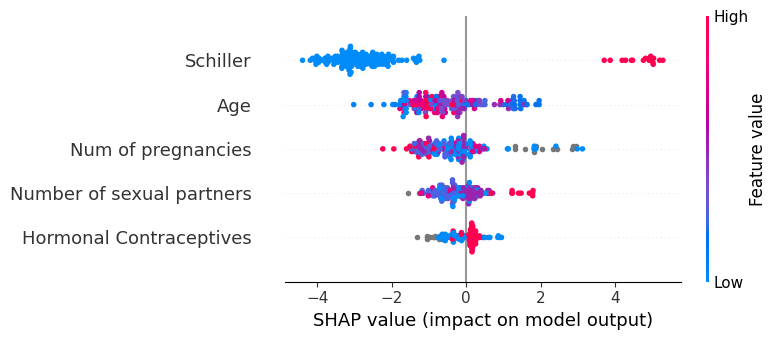

In [11]:
# Summary plot
shap.summary_plot(shap_values, X_test, max_display=10)